# Day-Ahead Electricity Demand Forecasting: A Robust Multi-Horizon Evaluation Framework

This notebook extends a baseline short-term forecasting pipeline into a more realistic **day-ahead electricity demand forecasting framework**.

The objective is not only to predict electricity demand at a +24h horizon, but to systematically evaluate model performance under increasingly realistic and challenging conditions.

In particular, the analysis explores how predictive performance is affected by:
- **forecasting horizon** (from +1h up to +24h)  
- **operational constraints** (limited access to recent observations via lag configurations)  
- **exogenous variables** (weather features such as temperature)  
- **evaluation methodology** (static vs rolling forecasting)  
- **extreme and out-of-distribution conditions** (stress testing scenarios) 

This transforms the project from a standard modeling exercise into a more **robust and industry-oriented forecasting analysis**.


## Workflow

1. Load and preprocess electricity and weather data  
2. Align timestamps and validate time-series consistency  
3. Construct target variables for multiple forecasting horizons (+1h, +3h, +6h, +24h)  
4. Perform feature engineering:
   - lag features under different availability constraints  
   - rolling statistics  
   - calendar and cyclical features  
   - weather-based exogenous variables  
5. Train baseline, statistical, and machine learning models  
6. Evaluate models using multiple validation strategies:
   - chronological train/test split  
   - time-series cross-validation  
   - rolling forecast evaluation  
7. Assess robustness under stress conditions:
   - peak demand periods  
   - extreme temperature scenarios  
   - temporal stability across the test horizon 


## Pipeline overview

Raw data → Time Alignment → Multi-horizon target definition → Feature Engineering → Model Training → Multi-level evaluation (Train/Test + CV + Rolling Forecast + Stress Testing)


## Models compared

### Baselines
- Naive forecast (t-24)

### Statistical models
- Exponential Smoothing (Holt-Winters)

### Machine learning models
- Ridge Regression
- Random Forest Regressor
- Gradient Boosting Regressor

The goal is to move from a simplified forecasting setup to a more realistic **day-ahead electricity demand forecasting pipeline**, where models are evaluated not only on average accuracy, but also on **robustness, operational realism, and behavior under challenging conditions**. Beyond accuracy, the focus is on model robustness, interpretability, and alignment with real-world energy forecasting constraints.

## Configuration

In [35]:
# =========================
# Project configuration
# =========================

DATA_PATH = "../data/PJME_hourly.csv"
TARGET_COL = "PJME_MW"

TEST_SIZE = 0.2
RANDOM_STATE = 42

# plotting window (first month)
PLOT_HOURS = 24 * 30

In [36]:
# ============================================================================
# Weather configuration: PJM East approximate center --> Philadelphia area
# ============================================================================

LAT = 39.95
LON = -75.16

## Imports

In [37]:
import os
import sys

sys.path.append(os.path.abspath(".."))

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.base import clone
from sklearn.model_selection import TimeSeriesSplit

from src.preprocessing import load_data, sort_by_time, run_data_checks
from src.weather import fetch_open_meteo_weather
from src.features import create_features
from src.train import (
    make_Xy,
    make_train_test_split,
    build_ridge_pipeline,
    build_random_forest_model,
    build_gradient_boosting_model,
    fit_predict,
)
from src.evaluate import rolling_forecast, evaluate_regression

## Data loading and preprocessing

The electricity demand dataset is loaded and prepared for analysis. Timestamps are standardized, converted to datetime format, and the series is sorted chronologically to ensure a consistent time-series structure suitable for forecasting.

In [39]:
df = load_data("../data/PJME_hourly.csv")
df = sort_by_time(df)

print("Raw shape:", df.shape)
df.head()

Raw shape: (145366, 1)


,PJME_MW
timestamp,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


## Data quality checks

Before feature engineering, a set of validation checks is performed to ensure the reliability and consistency of the time series. These checks include:

- ordering and continuity of timestamps  
- detection of duplicates and missing values  
- verification of the expected hourly frequency  
- identification of missing time steps across the full time range  

These steps are essential to guarantee temporal consistency, which is critical for the correct construction of lagged and rolling features used in forecasting models.

In [40]:
checks, time_deltas = run_data_checks(df)

print("Data checks")
for name, value in checks.items():
    print(f"- {name}: {value}")

print("\nMost common time deltas:")
print(time_deltas)

Data checks
- sorted_index: True
- duplicate_timestamps: 4
- missing_target_values: 0
- negative_target_values: 0
- missing_timestamps: 26

Most common time deltas:
timestamp
0 days 01:00:00    145331
0 days 02:00:00        30
0 days 00:00:00         4
Name: count, dtype: int64


In [ ]:
# remove duplicated timestamps, if any, keeping the first occurrence
df = df[~df.index.duplicated(keep="first")].copy()

print("Shape after duplicate handling:", df.shape)

Shape after duplicate handling: (145362, 1)


## Target definition and multi-horizon setup

To transform the problem into a supervised learning task, the target variable is defined by shifting the electricity demand forward in time. Rather than focusing on a single forecasting horizon, the analysis is extended to multiple horizons to better reflect real-world forecasting requirements. For each timestamp *t*, the model learns to predict the demand at *t + h*, where *h* represents the forecasting horizon.

The following horizons are considered:

- +1 hour (very short-term)  
- +3 hours (intra-day operational horizon)  
- +6 hours (short-term planning)  
- +24 hours (day-ahead baseline)  

For each horizon, the target variable is shifted accordingly while keeping the rest of the pipeline unchanged. This allows for a controlled comparison of model performance as a function of forecast horizon.

This setup serves two main purposes:

- evaluate how predictive performance degrades as the forecasting horizon increases  
- assess model robustness under different operational constraints  

All features are constructed using only information available up to time *t*, ensuring strict temporal causality and preventing data leakage.

In [ ]:
HORIZONS = [1, 3, 6, 24]  # hours ahead

df_horizons = {}
df = df.sort_index()

for h in HORIZONS:
    df_h = df.copy()
    
    # shift target
    df_h["target"] = df_h[TARGET_COL].shift(-h)

    df_h = df_h.dropna(subset=["target"])   
    df_horizons[h] = df_h
    print(f"Horizon +{h}h -> shape: {df_h.shape}")

Horizon +1h -> shape: (145361, 2)
Horizon +3h -> shape: (145359, 2)
Horizon +6h -> shape: (145356, 2)
Horizon +24h -> shape: (145338, 2)


## Weather data integration (Open-Meteo API)

To improve the realism and predictive power of the forecasting pipeline, external weather data is incorporated.

Electricity demand is strongly influenced by temperature, particularly due to heating and cooling effects. Therefore, temperature is introduced as an exogenous variable. Hourly temperature data is retrieved from the Open-Meteo API and aligned with the PJM electricity demand timestamps.


### Why weather data matters

- captures seasonal consumption patterns  
- improves model performance under extreme temperature conditions  
- provides exogenous explanatory power beyond pure autocorrelation  


## Weather-energy data alignment

Weather data is merged with electricity demand using timestamp alignment. This ensures:
- no data leakage  
- correct temporal correspondence between features and target  
- consistent hourly frequency across datasets

In [43]:
start_date = df.index.min().date()
end_date = df.index.max().date()

weather_df = fetch_open_meteo_weather(
    latitude=LAT,
    longitude=LON,
    start_date=start_date,
    end_date=end_date,
    timezone="UTC"
)

df = df.reset_index().rename(columns={"index": "timestamp"})
df = df.merge(weather_df, on="timestamp", how="left")
df = df.set_index("timestamp")

print(df[["PJME_MW", "temperature"]].head())

                     PJME_MW  temperature
timestamp                                
2002-01-01 01:00:00  30393.0         -3.5
2002-01-01 02:00:00  29265.0         -3.7
2002-01-01 03:00:00  28357.0         -3.8
2002-01-01 04:00:00  27899.0         -4.1
2002-01-01 05:00:00  28057.0         -4.4


In [44]:
print("Missing temperature values:", df["temperature"].isna().sum())

print(df[["PJME_MW", "temperature"]].describe())

Missing temperature values: 0
             PJME_MW    temperature
count  145362.000000  145362.000000
mean    32080.510780      12.857221
std      6463.866507      10.289055
min     14544.000000     -21.900000
25%     27573.000000       4.600000
50%     31421.000000      13.400000
75%     35650.000000      21.400000
max     62009.000000      39.900000


## Feature engineering

To improve forecasting performance, a comprehensive set of features is engineered to capture both internal demand dynamics and external drivers. The feature set includes:

- **Temporal features**: hour of day, day of week, month, and weekend indicators  
- **Cyclical encoding**: sine/cosine transformations to represent periodic time structures  
- **Autoregressive components**: lagged electricity demand values to capture short- and long-term dependencies  
- **Rolling statistics**: moving averages and variability measures to model local trends and volatility  
- **Weather-based features**: temperature and derived indicators capturing heating and cooling effects  

All features are strictly computed using past information only, ensuring no data leakage and preserving the causal structure required for time-series forecasting.

Feature engineering is applied after target definition for each forecasting horizon, ensuring that each observation contains only information available up to time *t*, while the target corresponds to demand at time *t + h*. This guarantees a realistic supervised learning setup aligned with real-world forecasting conditions.


### Lag constraint analysis (operational scenario)

In real-world energy forecasting, models are often subject to operational constraints that limit access to the most recent observations. Due to data latency, processing delays, or market gate closure requirements, the latest available demand at prediction time may not correspond to *t-1*, but rather to an earlier time step (e.g. *t-3* or beyond).

To simulate this setting, a **lag constraint scenario** is introduced, where the model is restricted from using the most recent lag (`lag_1`) and instead relies on less recent information (e.g. `lag_3` and beyond). This allows evaluating:
- the dependence of model performance on immediate past observations  
- the robustness of models under limited information availability  
- the degradation in forecasting accuracy under operational delays  

This analysis reflects real-world constraints in energy systems, where forecasts must be generated ahead of time under strict timing requirements.

In [ ]:
# 1. standard scenario (lag_1 available)
df_feat = create_features(df)

print("Feature matrix shape (lag_1):", df_feat.shape)

# 2. constrained scenario (no lag_1)
df_feat_lag3 = create_features(df, use_lag1=False)

print("Feature matrix shape (lag_3 scenario):", df_feat_lag3.shape)

Feature matrix shape (lag_1): (145194, 21)
Feature matrix shape (lag_3 scenario): (145194, 20)


## Train/test split

Given the temporal structure of the dataset, a **chronological train/test split** is used instead of a random split. This approach ensures that the model is trained exclusively on past data and evaluated on future observations, mimicking a real-world forecasting scenario. This prevents information leakage and ensures that performance metrics reflect true out-of-sample predictive capability.

In particular:
- the training set contains earlier time periods
- the test set contains later, unseen observations
- no shuffling is applied

Such a setup is essential in energy forecasting applications, where models must generalize to unseen future conditions. This evaluation serves as a baseline, which is later complemented by more advanced validation strategies such as rolling forecasting and stress testing.

In [48]:
X, y = make_Xy(df_feat, target_col=TARGET_COL)
X_train, X_test, y_train, y_test = make_train_test_split(X, y, test_size=TEST_SIZE)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (116155, 20)
X_test : (29039, 20)
y_train: (116155,)
y_test : (29039,)


## Forecasting models

To evaluate different approaches to the forecasting problem, I considered three categories of models:
1. a naive baseline model
2. a statistical time-series model (Exponential Smoothing)
3. machine learning models (Ridge, Random Forest, Gradient Boosting)

This comparison allows assessing the trade-off between simplicity, interpretability, and predictive performance.

## 1. Baseline model

Before training machine learning models, a simple baseline is established to provide a reference level of performance.

In particular, I made use of a **naive forecast** based on historical demand patterns. In the day-ahead setting (+24h), demand at time *t + 24h* is approximated using the demand observed at time *t*. For shorter horizons, this baseline naturally relies on the most recent available observations, providing a strong reference due to the high autocorrelation of electricity demand. 

Comparing advanced models against this baseline helps assess whether the added complexity provides meaningful improvements.

In [49]:
test_results = {}
predictions = {}

y_pred_naive = X_test["lag_24"]

test_results["Naive"] = evaluate_regression(y_test, y_pred_naive)
predictions["Naive"] = y_pred_naive

print("Naive baseline performance:")
for key, value in test_results["Naive"].items():
    print(f"{key}: {value:.4f}")

Naive baseline performance:
rmse: 3008.9402
mae: 2184.0242
r2: 0.7851


## 2. Statistical model

In addition to the naive baseline, a statistical time-series model is used as a benchmark.

In particular, I applied a **Exponential Smoothing (Holt-Winters)** to capture level, trend, and seasonality components in the electricity demand. This type of model is widely used in energy forecasting due to its interpretability and ability to model structured temporal patterns. It also provides a strong reference point, especially for longer forecasting horizons.

Unlike machine learning models, this approach does not rely on exogenous variables, but instead models the internal structure of the time series directly.

In [50]:
ts = df["PJME_MW"].sort_index().asfreq("h").ffill()

hw_train_size = int(len(ts) * (1 - TEST_SIZE))
hw_train, hw_test = ts.iloc[:hw_train_size], ts.iloc[hw_train_size:]

# Fit only on training data
hw_model = ExponentialSmoothing(
    hw_train,
    trend="add",
    seasonal="add",
    seasonal_periods=24
)

hw_fit = hw_model.fit()

# Forecast on test horizon
y_pred_hw = hw_fit.forecast(len(hw_test))

test_results["Exponential Smoothing"] = evaluate_regression(hw_test, y_pred_hw)
predictions["Exponential Smoothing"] = y_pred_hw

print("\nExponential Smoothing performance:")
for key, value in test_results["Exponential Smoothing"].items():
    print(f"{key}: {value:.4f}")


Exponential Smoothing performance:
rmse: 6046.8454
mae: 4416.7364
r2: 0.1313


Exponential Smoothing captures general trend and daily seasonality, but shows limited ability to model external drivers and nonlinear effects. As a result, its performance is moderate compared to machine learning approaches, which benefit from richer feature sets such as lag structures and weather variables.

## 3. Machine learning models

To complement the baseline and statistical approaches, several machine learning models are trained to capture complex patterns in electricity demand.

In particular, I considered the following models:
- **Ridge Regression**, a regularized linear model used as a robust baseline, implemented within a scikit-learn Pipeline  
- **Random Forest Regressor**, an ensemble method based on decision trees, capable of capturing nonlinear relationships  
- **Gradient Boosting Regressor**, a boosting-based ensemble model that incrementally improves prediction accuracy

This setup enables a direct comparison between a simple linear approach and more flexible nonlinear models.

All models are trained on the same feature set and evaluated consistently across different validation strategies, ensuring a fair and robust comparison with the naive baseline and the statistical model.

The use of a dictionary of models keeps the workflow modular, scalable, and easy to extend with additional estimators.

In [51]:
ridge = build_ridge_pipeline()
rf = build_random_forest_model()
gb = build_gradient_boosting_model()

models = {
    "Ridge": ridge,
    "Random Forest": rf,
    "Gradient Boosting": gb,
}

for name, model in models.items():
    y_pred = fit_predict(model, X_train, y_train, X_test)
    test_results[name] = evaluate_regression(y_test, y_pred)
    predictions[name] = y_pred

    print(f"\n{name} performance:")
    for key, value in test_results[name].items():
        print(f"{key}: {value:.4f}")


Ridge performance:
rmse: 665.5061
mae: 507.6600
r2: 0.9895

Random Forest performance:
rmse: 361.6084
mae: 255.0962
r2: 0.9969

Gradient Boosting performance:
rmse: 561.7647
mae: 436.5973
r2: 0.9925


In [52]:
results_df = (
    pd.DataFrame(test_results)
    .T
    .sort_values("rmse")
    .round(2)
)

results_df

,rmse,mae,r2
Random Forest,361.61,255.10,1.00
Gradient Boosting,561.76,436.60,0.99
Ridge,665.51,507.66,0.99
Naive,3008.94,2184.02,0.79
Exponential Smoothing,6046.85,4416.74,0.13


## Test-set performance

The table above compares all models on the holdout test set using:
- **RMSE**: penalizes large errors more strongly  
- **MAE**: average absolute error  
- **R²**: proportion of explained variance  

The results show a clear hierarchy of performance across model classes.

Naive and statistical approaches provide useful baselines. The Naive model already achieves reasonable accuracy due to the strong autocorrelation in electricity demand, while Exponential Smoothing captures general trend and daily seasonality but shows limited ability to model external drivers and nonlinear effects. Unlike machine learning models, this approach does not rely on exogenous variables, but instead models the internal structure of the time series directly. As a result, its performance is moderate compared to machine learning approaches, which benefit from richer feature sets such as lag structures and weather variables.

Linear models (Ridge Regression) already achieve strong performance, explaining most of the variance in the data. However, tree-based ensemble models further improve predictive accuracy by capturing nonlinear relationships and feature interactions. Among all models, **Random Forest** achieves the best overall performance in terms of RMSE and R², followed closely by **Gradient Boosting**, which also provides strong predictive power but slightly higher error in this configuration.

In [53]:
best_model_name = results_df.index[0]
y_pred_best = predictions[best_model_name]
best_model_name

'Random Forest'

## Test-set prediction plots

To better understand model performance, I visualize predictions over time. Rather than focusing only on aggregate metrics, these plots show how well the models capture the temporal dynamics of electricity demand.

For readability, the analysis focuses on the first month of the test period. Two complementary visualizations are presented:

1. **Actual vs predicted demand (best model)**  
   → to assess how accurately the model captures temporal patterns and short-term dynamics  

2. **Actual vs predicted vs naive baseline**  
   → to evaluate the improvement over a simple benchmark and quantify the added value of the model  

Together, these plots provide both an absolute and relative view of model performance.

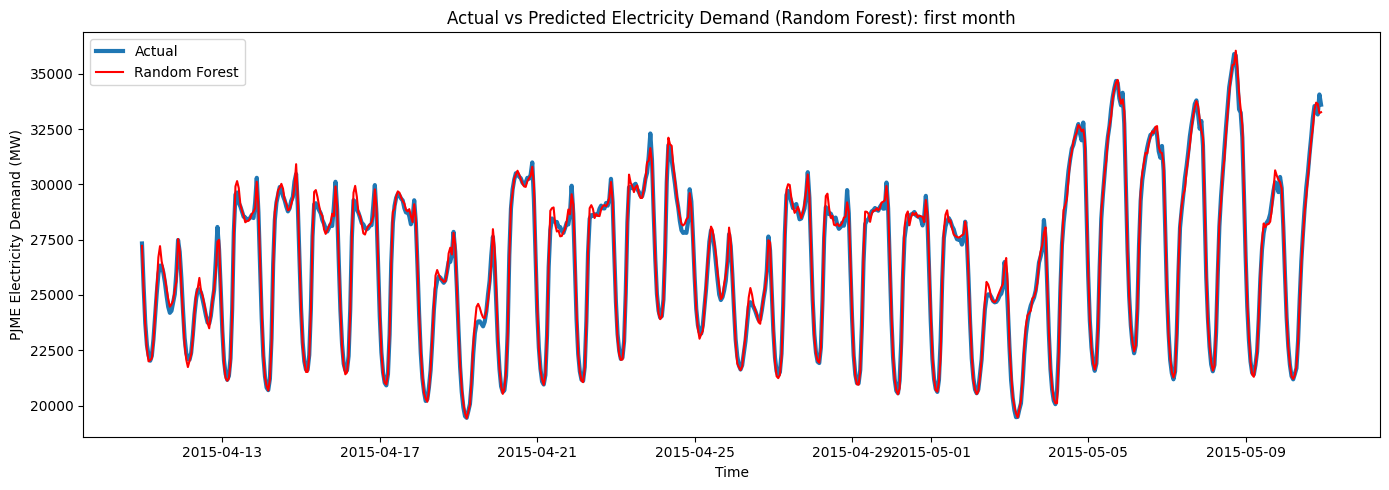

In [54]:
y_pred_naive = pd.Series(y_pred_naive, index=y_test.index)
y_pred_best = pd.Series(y_pred_best, index=y_test.index)

plt.figure(figsize=(14, 5))
plt.plot(
    y_test.iloc[:PLOT_HOURS].index,
    y_test.iloc[:PLOT_HOURS],
    label="Actual",
    linewidth=3
)
plt.plot(
    y_pred_best.iloc[:PLOT_HOURS].index,
    y_pred_best.iloc[:PLOT_HOURS],
    label=best_model_name,
    color="red"
)
plt.title("Actual vs Predicted Electricity Demand (Random Forest): first month")
plt.xlabel("Time")
plt.ylabel("PJME Electricity Demand (MW)")
plt.legend()
plt.tight_layout()
plt.savefig("../images/predictions_rf.png", dpi=300, bbox_inches="tight")
plt.show()

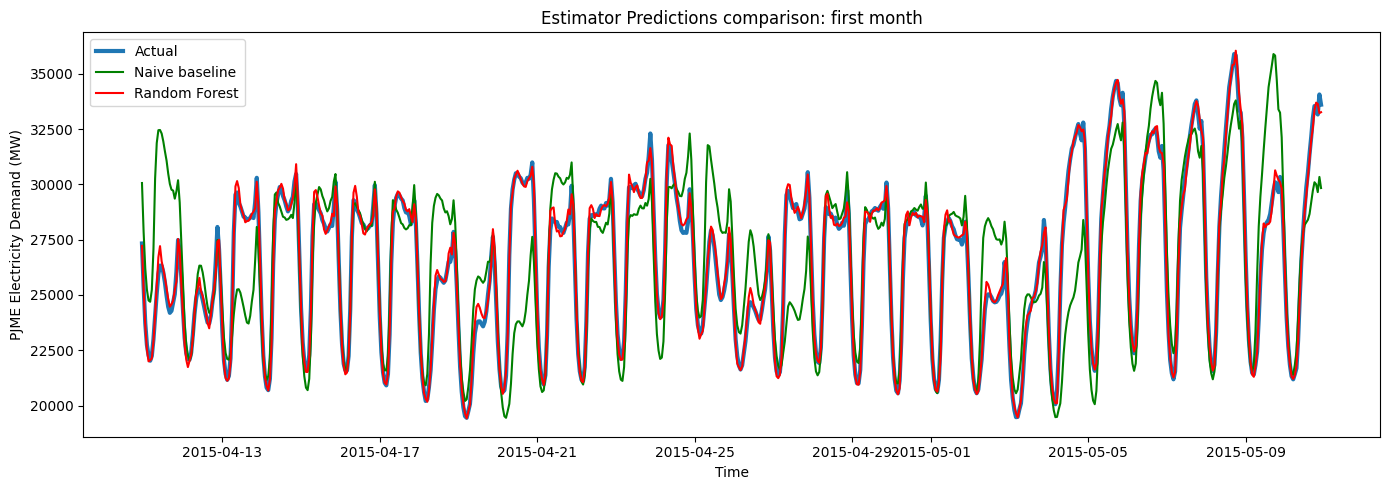

In [55]:
plt.figure(figsize=(14, 5))
plt.plot(
    y_test.iloc[:PLOT_HOURS].index,
    y_test.iloc[:PLOT_HOURS],
    label="Actual",
    linewidth=3
)
plt.plot(
    predictions["Naive"].iloc[:PLOT_HOURS].index,
    predictions["Naive"].iloc[:PLOT_HOURS],
    label="Naive baseline",
    color="green"
)
plt.plot(
    y_pred_best.iloc[:PLOT_HOURS].index,
    y_pred_best.iloc[:PLOT_HOURS],
    label=best_model_name,
    color="red"
)
plt.title("Estimator Predictions comparison: first month")
plt.xlabel("Time")
plt.ylabel("PJME Electricity Demand (MW)")
plt.legend()
plt.tight_layout()
plt.show()

## Rolling forecast evaluation (operational realism)

While a single chronological train/test split provides a useful first estimate of model performance, it still represents a simplified evaluation setup. In real-world energy forecasting systems, models are not trained once and evaluated statically. Instead, forecasts are generated continuously over time, using only the most recent historical information available at the prediction timestamp.

To better simulate this behavior, I implement a **sliding window rolling forecast evaluation strategy**. At each step:
- the model is trained on the most recent `window_size` observations  
- a prediction is generated for the next `step` horizon (*t + h*, e.g. 24 or 48 hours)  
- the training window remains fixed in size, shifting forward over time  

This approach mimics real-world forecasting systems where older data gradually becomes less relevant, while keeping computational cost stable.

### Why rolling forecasting matters
- provides a more realistic estimate of model performance  
- captures temporal variability in model accuracy  
- avoids optimistic bias due to static training sets  
- improves computational efficiency compared to expanding window approaches  
- better reflects operational forecasting workflows  

This step directly addresses a key limitation of offline evaluation and bridges the gap between a modeling exercise and a real-world forecasting system.

In [56]:
rf_model = build_random_forest_model(
    n_estimators=80,
    max_depth=12
)

X_full, y_full = make_Xy(df_feat, target_col=TARGET_COL)

initial_train_size = int(len(X_full) * (1 - TEST_SIZE))

y_true_rf, y_pred_rf = rolling_forecast(
    rf_model,
    X_full,
    y_full,
    initial_train_size=initial_train_size,
    step=48,
    window_size=5000
)

results_rf = evaluate_regression(y_true_rf, y_pred_rf)

print("Rolling Forecast Performance (Random Forest - Sliding Window)")
for metric, value in results_rf.items():
    print(f"{metric}: {value:.2f}")

Rolling Forecast Performance (Random Forest - Sliding Window)
rmse: 613.29
mae: 418.57
r2: 0.99


## Comparison: test-set vs rolling forecast performance

The rolling forecast shows a clear degradation in performance compared to the test-set evaluation. This reflects a more realistic scenario, where the model is repeatedly retrained and used to predict future observations over time. 

As expected:
- errors increase under rolling evaluation  
- performance estimates become less optimistic  
- temporal variability is more accurately captured  

Despite this, the model maintains a high explanatory power, indicating that it remains reliable even in a dynamic setting.

The comparison highlights the gap between idealized evaluation and real-world performance, while confirming the overall robustness of the model.

## Rolling forecast plot

To evaluate model performance under realistic operating conditions, I visualize predictions generated through the rolling forecast strategy.

For readability, the analysis focuses on the first month of the test period. The plot shows the comparison between actual electricity demand and model predictions across a moving time window, highlighting how well the model adapts to evolving patterns in the data.

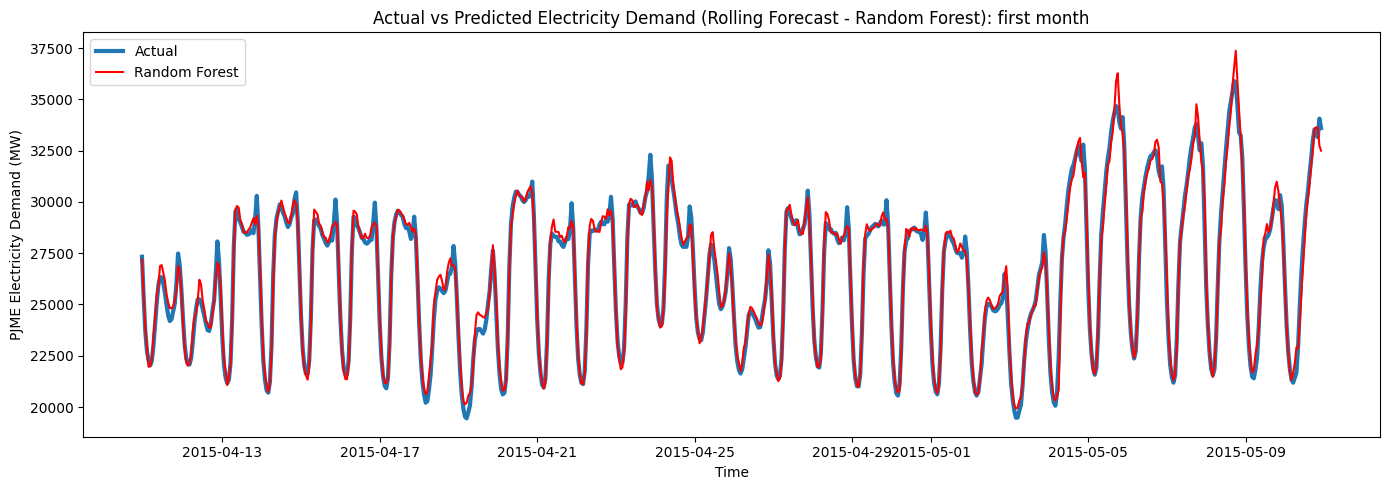

In [58]:
plt.figure(figsize=(14,5))
plt.plot(
    y_test.index[:PLOT_HOURS],
    y_true_rf[:PLOT_HOURS],
    label="Actual",
    linewidth=3
)
plt.plot(
    y_test.index[:PLOT_HOURS],
    y_pred_rf[:PLOT_HOURS],
    label=best_model_name,
    color="red"
)
plt.title("Actual vs Predicted Electricity Demand (Rolling Forecast - Random Forest): first month")
plt.xlabel("Time")
plt.ylabel("PJME Electricity Demand (MW)")
plt.legend()
plt.tight_layout()
plt.show()

## Stress Test and Extrapolation Analysis

To assess model robustness beyond standard test-set evaluation, a stress test is conducted on challenging operating conditions. While standard metrics evaluate average performance, real-world forecasting systems must remain reliable under extreme and rare events, such as peak electricity demand or unusual weather conditions.


## Why stress testing matters
- evaluates model robustness under distribution shifts  
- rests performance during extreme demand periods  
- identifies potential failure modes in real-world deployment  
- complements standard train/test evaluation  


## Stress scenarios

The analysis focuses on three challenging regimes:
- peak demand conditions (top 5% highest electricity consumption values)  
- extreme temperature conditions (very hot or very cold weather)  
- temporal shift analysis (performance stability over different time segments)  

This provides a deeper understanding of how the model behaves beyond average conditions.

In [59]:
threshold = y_test.quantile(0.95)

peak_idx = y_test[y_test >= threshold].index

y_true_peak = y_test.loc[peak_idx]
y_pred_peak = pd.Series(y_pred_best, index=y_test.index).loc[peak_idx]

peak_results = evaluate_regression(y_true_peak, y_pred_peak)

print("Peak Demand Stress Test")
for k, v in peak_results.items():
    print(f"{k}: {v:.2f}")

Peak Demand Stress Test
rmse: 456.15
mae: 323.73
r2: 0.98


In [60]:
temp = X_test["temperature"]

temp_threshold_low = temp.quantile(0.05)
temp_threshold_high = temp.quantile(0.95)

extreme_idx = temp[(temp <= temp_threshold_low) | (temp >= temp_threshold_high)].index

y_true_ext = y_test.loc[extreme_idx]
y_pred_ext = pd.Series(y_pred_best, index=y_test.index).loc[extreme_idx]

extreme_results = evaluate_regression(y_true_ext, y_pred_ext)

print("Extreme Temperature Stress Test")
for k, v in extreme_results.items():
    print(f"{k}: {v:.2f}")

Extreme Temperature Stress Test
rmse: 451.79
mae: 330.60
r2: 0.99


In [61]:
split_point = int(len(y_test) * 0.5)

first_half_idx = y_test.index[:split_point]
second_half_idx = y_test.index[split_point:]

def eval_segment(idx, name):
    yt = y_test.loc[idx]
    yp = pd.Series(y_pred_best, index=y_test.index).loc[idx]
    res = evaluate_regression(yt, yp)
    print(f"\n{name}")
    for k, v in res.items():
        print(f"{k}: {v:.2f}")

eval_segment(first_half_idx, "First half test period")
eval_segment(second_half_idx, "Second half test period")


First half test period
rmse: 341.64
mae: 240.36
r2: 1.00

Second half test period
rmse: 380.53
mae: 269.83
r2: 1.00


Performance degrades under stress conditions compared to the overall test-set evaluation, particularly during peak demand periods. This indicates that extreme load conditions are more difficult to predict and introduce higher error levels.

Under extreme temperature conditions, the model maintains relatively strong performance, suggesting that it effectively captures the relationship between weather variables and electricity demand.

The temporal split analysis shows consistent performance across different segments of the test period, with only a slight degradation in the second half. This indicates that the model remains stable over time and does not suffer from significant performance drift.

Overall, the model demonstrates good robustness under distribution shifts and challenging scenarios. While errors increase in extreme conditions, performance remains strong and stable, confirming the model’s reliability for real-world forecasting applications.

## Feature Importance

For interpretability, I analyze feature importance from the Random Forest model trained on the final feature set.

This helps answer a practical question: **which signals are most influential in predicting electricity demand?** In time series forecasting, lagged variables are typically the most important predictors because electricity demand exhibits strong temporal autocorrelation and daily/weekly repetition patterns.

In [62]:
random_forest_model = models["Random Forest"]

feature_importances = (
    pd.Series(random_forest_model.feature_importances_, index=X_train.columns)
    .sort_values(ascending=False)
)

feature_importances.head(10)

lag_1                0.949312
hour_cos             0.023479
hour                 0.008573
lag_3                0.006973
hour_sin             0.003550
rolling_mean_24      0.002421
temp_roll_mean_24    0.001121
month                0.000526
temp_lag_1           0.000500
dow_sin              0.000452
dtype: float64

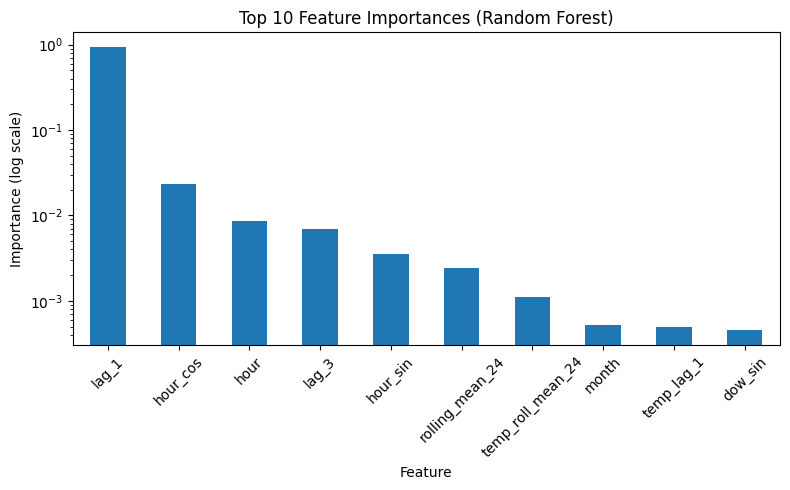

In [63]:
plt.figure(figsize=(8, 5))
feature_importances.head(10).plot(kind="bar")
plt.yscale("log")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Feature")
plt.ylabel("Importance (log scale)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/feature_importance_rf.png", dpi=300, bbox_inches="tight")
plt.show()

The feature importance analysis from the final Random Forest model shows a highly consistent and interpretable pattern across both model versions.

The dominant feature is **`lag_1`**, which by a very large margin carries the highest predictive power. This confirms that electricity demand is extremely dependent on its most recent value, highlighting a **strong short-term autocorrelation** in the time series.

Among the remaining predictors, calendar-based features such as `hour`, `hour_sin`, and `hour_cos` provide the second most relevant source of information. These variables capture the strong **daily seasonality** present in electricity consumption, reflecting predictable intra-day usage patterns.

Rolling statistics (e.g. `rolling_mean_24`, `rolling_std_24`) contribute modestly to the model, suggesting that short-term aggregated behavior adds some value but is largely secondary compared to direct lagged signals.

In the extended feature set, weather-related variables such as `temp_roll_mean_24`, `temp_lag_1`, and `temp_lag_24` appear with low but non-zero importance. This indicates that temperature has a measurable influence on demand, although its effect is significantly weaker than intrinsic temporal dependencies. The presence of these features confirms that external drivers do improve the model, but only marginally in a short-term forecasting context.

Overall, the results reinforce a clear **hierarchy of predictive signals**: recent demand history is the primary driver, followed by daily seasonal structure, while weather and rolling statistics provide incremental improvements. This is consistent with typical behavior in short-term electricity load forecasting problems, where **autoregressive structure dominates predictive performance**.

## Time Series Cross-Validation

While a single train/test split provides a first estimate of model performance, it may be sensitive to the specific temporal partition of the data.

To obtain a more robust and reliable evaluation, I apply **TimeSeriesSplit cross-validation**, which preserves the chronological structure of the data and prevents any leakage from future observations into the training set.

Unlike standard cross-validation, this approach evaluates the models on sequentially expanding training windows, better reflecting a real-world forecasting scenario where predictions are always made on unseen future data.

In [64]:
tsscv = TimeSeriesSplit(n_splits=5)

cv_results = {name: [] for name in models}

for train_idx, val_idx in tsscv.split(X):
    X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
    y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]

    for name, model in models.items():
        model_cv = clone(model)
        preds_cv = fit_predict(model_cv, X_train_cv, y_train_cv, X_val_cv)

        rmse_cv = evaluate_regression(y_val_cv, preds_cv)["rmse"]
        cv_results[name].append(rmse_cv)

cv_rmse_df = pd.DataFrame(cv_results, index=[f"Fold {i}" for i in range(1, 6)])
cv_rmse_df.round(2)

,Ridge,Random Forest,Gradient Boosting
Fold 1,782.75,475.93,635.81
Fold 2,757.67,345.99,563.69
Fold 3,742.32,355.91,595.58
Fold 4,705.93,364.55,585.70
Fold 5,671.04,357.95,572.39


In [65]:
cv_summary_df = pd.DataFrame({
    "mean_rmse": cv_rmse_df.mean(),
    "std_rmse": cv_rmse_df.std()
}).sort_values("mean_rmse").round(2)

cv_summary_df

,mean_rmse,std_rmse
Random Forest,380.07,54.00
Gradient Boosting,590.64,28.06
Ridge,731.94,43.98


The table above presents the results of **Time Series Cross-Validation (5 folds)** applied to the machine learning models, along with the mean and standard deviation of RMSE. Overall, the results show a **consistent ranking across all temporal splits**, confirming the robustness of the evaluation.

**Random Forest achieves the best performance in every fold**, with an average RMSE of approximately **380 MW**, significantly outperforming both Gradient Boosting and Ridge Regression. This confirms its **strong ability to capture nonlinear patterns in electricity demand**.

**Gradient Boosting also performs competitively**, but consistently shows higher error compared to Random Forest. However, it exhibits relatively low variance across folds, suggesting **stable but slightly more conservative predictions**.

The linear baseline (**Ridge Regression**) performs substantially worse across all folds, with RMSE values consistently above **700 MW**. This indicates that a **linear formulation is not sufficient to capture the nonlinear structure of electricity demand dynamics**.

In terms of stability, **Random Forest provides the best balance between accuracy and robustness**, maintaining low variability across folds while achieving the lowest error. **Gradient Boosting shows slightly lower variance**, but at the cost of higher bias, indicating more conservative learning behavior. **Ridge Regression, while stable, clearly underfits the data**.

Time Series Cross-Validation was applied exclusively to machine learning models because these approaches rely on **feature-based learning** and are sensitive to the distribution of training data across different temporal windows. Unlike rolling forecasting and stress testing, which evaluate model behavior under **operational and extreme-condition scenarios**, this approach provides a **controlled assessment of performance across multiple training-validation splits**. **Naive forecasting and Exponential Smoothing were evaluated on a single holdout test set**, as they serve as baseline benchmarks and are not designed for iterative retraining or feature-based learning.

## Final conclusions

This project demonstrates a complete and realistic machine learning pipeline for **day-ahead electricity demand forecasting**, extending a baseline setup with more advanced modeling and evaluation strategies.

A central role is played by feature engineering. Lag variables and temporal features effectively capture the strong autocorrelation and recurring daily patterns that characterize electricity demand, while weather variables introduce additional exogenous information.

Beyond standard evaluation, the project incorporates multiple validation strategies to better reflect real-world forecasting conditions, including time-series cross-validation, rolling forecasting, and stress testing.


### Main findings

- **Lag-based features remain the dominant source of predictive signal**, confirming the strong short-term persistence of electricity demand.
- **Forecast accuracy degrades as the prediction horizon increases**, highlighting the growing importance of external drivers and more complex temporal patterns.
- **Operational constraints matter**: restricting access to recent observations (lag constraint scenario) leads to measurable performance degradation.
- **Tree-based ensemble models outperform linear models**, indicating the presence of nonlinear relationships and feature interactions.
- Across all evaluation strategies, **Random Forest consistently achieves the best performance**, balancing accuracy and robustness.
- **Rolling forecast evaluation reveals a performance drop compared to static test-set evaluation**, providing a more realistic estimate of real-world behavior.
- **Stress testing shows that model performance deteriorates under extreme conditions**, especially during peak demand and temperature anomalies.

Overall, the results highlight that accurate electricity demand forecasting requires not only strong models, but also **careful evaluation under realistic and operationally relevant conditions**.

Future improvements could include advanced boosting methods (e.g. XGBoost, LightGBM), probabilistic forecasting, and deployment in a real-time prediction setting.